# Preliminary QSVM/QSVC Baseline

Midterm documentation of the completed reduced-subset QSVM experiment.

## 1. Objective

This notebook explains and inspects the already completed preliminary QSVM/QSVC experiment. It loads the saved results and predictions; it does not run a new quantum experiment.

## 2. QSVM architecture

The implemented hybrid pipeline is:

`classical features -> training-only feature reduction -> 4-qubit zz_feature_map -> quantum states -> FidelityQuantumKernel -> kernel matrix -> classical QSVC -> predictions`.

The quantum circuit supplies the feature-space similarity calculation. QSVC performs the support-vector classification using that kernel.

## 3. Why only 4 features / 4 qubits

A feature map encodes one input dimension per qubit in this experiment. Four features therefore require four qubits. Keeping the representation small makes the circuit and kernel calculations feasible for a preliminary midterm experiment. This reduction does not make a full 227,845-sample quantum-kernel training run practical.

## 4. Selected features

The reusable training-only ANOVA F-score selector selected `V17`, `V14`, `V12`, and `V10`. Selection was fitted on the baseline training partition only; the test subset was used only after selection, for held-out prediction.

## 5. Quantum feature map

The current function-based Qiskit API `zz_feature_map` encodes the four classical values into four qubits. The experiment uses `reps = 1` and `entanglement = linear`. The ZZ interactions provide a compact second-order encoding.

## 6. Quantum kernel

`ComputeUncompute` with `StatevectorSampler` estimates the fidelity between feature-map states. `FidelityQuantumKernel` turns those fidelities into a kernel matrix. Conceptually,

$$K(x, y) = |\langle \phi(x) \mid \phi(y) \rangle|^2.$$

The saved training kernel matrix has shape 32 by 32.

## 7. QSVC

`QSVC` is the classical support-vector classifier supplied with a quantum kernel. This is why the method is hybrid: quantum circuits calculate the kernel similarities, while the classifier uses classical SVM optimization.

## 8. Training/test subset protocol

The original baseline split remains an 80/20 stratified random split with seed 42: 227,845 training rows and 56,962 test rows.

For this preliminary QSVM only, a deterministic 32-row training subset was selected from the baseline training partition, with 16 non-fraud and 16 fraud rows. A separate deterministic 32-row test subset was selected from the baseline test partition, also with 16 non-fraud and 16 fraud rows. The test subset did not influence preprocessing, feature selection, or model fitting.

## 9. Why reduced subsets

A quantum-kernel SVM requires many pairwise kernel evaluations. The earlier attempt to score all 56,962 baseline test rows was computationally prohibitive. The 32/32 subsets were therefore chosen explicitly for a repeatable preliminary workload.

This is a reduced-subset preliminary QSVM experiment. Its results are **not directly equivalent** to the full-data classical baseline results and do not establish quantum advantage.

## 10. Experimental configuration

The next cell loads the exact saved configuration rather than reconstructing or rerunning the experiment.

In [1]:
from pathlib import Path
import json
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RESULTS_PATH = PROJECT_ROOT / 'results' / 'json' / 'qsvm_results.json'
PREDICTIONS_PATH = PROJECT_ROOT / 'results' / 'json' / 'qsvm_predictions.json'
FIGURES_DIRECTORY = PROJECT_ROOT / 'results' / 'figures' / 'qsvm'
results = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))
predictions = json.loads(PREDICTIONS_PATH.read_text(encoding='utf-8'))
assert results['status'] == 'completed'
assert len(predictions) == results['test_set']['rows_used']
print('Loaded saved experiment:', results['experiment'])
print('No QSVC training is performed in this notebook.')

Loaded saved experiment: preliminary_reduced_subset_qsvm_midterm
No QSVC training is performed in this notebook.


In [2]:
configuration = {
    'selected features': ', '.join(results['feature_reduction']['selected_features']),
    'feature count': results['quantum_configuration']['feature_count'],
    'qubit count': results['quantum_configuration']['qubit_count'],
    'feature map': results['quantum_configuration']['feature_map'],
    'reps': results['quantum_configuration']['feature_map_reps'],
    'entanglement': results['quantum_configuration']['feature_map_entanglement'],
    'sampler': results['quantum_configuration']['sampler'],
    'shots': results['quantum_configuration']['shots'],
    'fidelity': results['quantum_configuration']['fidelity_implementation'],
    'kernel': results['quantum_configuration']['kernel_type'],
    'classifier': 'QSVC',
    'random seed': results['reproducibility']['random_state'],
}
display(configuration)

{'selected features': 'V17, V14, V12, V10',
 'feature count': 4,
 'qubit count': 4,
 'feature map': 'zz_feature_map',
 'reps': 1,
 'entanglement': 'linear',
 'sampler': 'StatevectorSampler',
 'shots': 1024,
 'fidelity': 'ComputeUncompute',
 'kernel': 'FidelityQuantumKernel',
 'classifier': 'QSVC',
 'random seed': 42}

## 11. Results

PR-AUC is the primary metric because the original fraud dataset is severely imbalanced. These values are the actual saved results from the balanced 32-row sanity-check test subset.

In [3]:
metrics = results['metrics']
result_summary = {
    'PR-AUC (Average Precision)': metrics['pr_auc'],
    'ROC-AUC': metrics['roc_auc'],
    'Precision': metrics['precision'],
    'Recall': metrics['recall'],
    'F1': metrics['f1'],
    'Specificity': metrics['specificity'],
    'FPR': metrics['false_positive_rate'],
}
display(result_summary)

{'PR-AUC (Average Precision)': 0.5384270461765968,
 'ROC-AUC': 0.52734375,
 'Precision': 0.5,
 'Recall': 0.375,
 'F1': 0.42857142857142855,
 'Specificity': 0.625,
 'FPR': 0.375}

## 12. Confusion matrix

The saved confusion matrix is TN=10, FP=6, FN=10, TP=6. It describes this reduced, balanced test subset only.

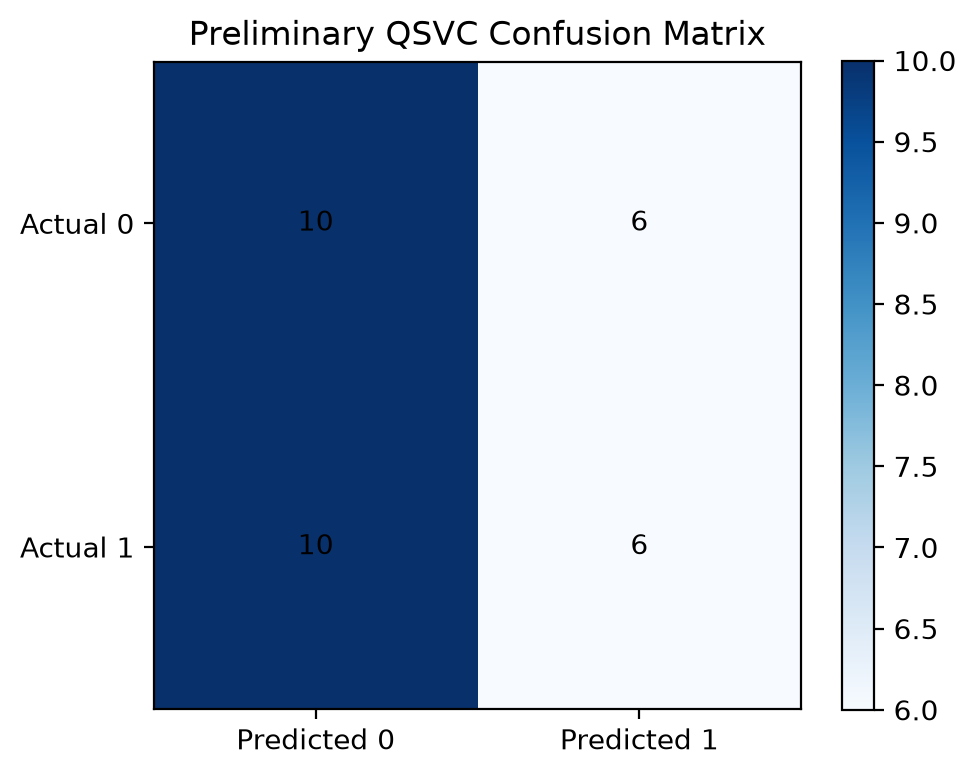

In [4]:
display(Image(filename=str(FIGURES_DIRECTORY / '03_confusion_matrix.png')))

## 13. PR curve

The plotted precision-recall curve uses the saved QSVC ranking scores. Its Average Precision is the saved PR-AUC value.

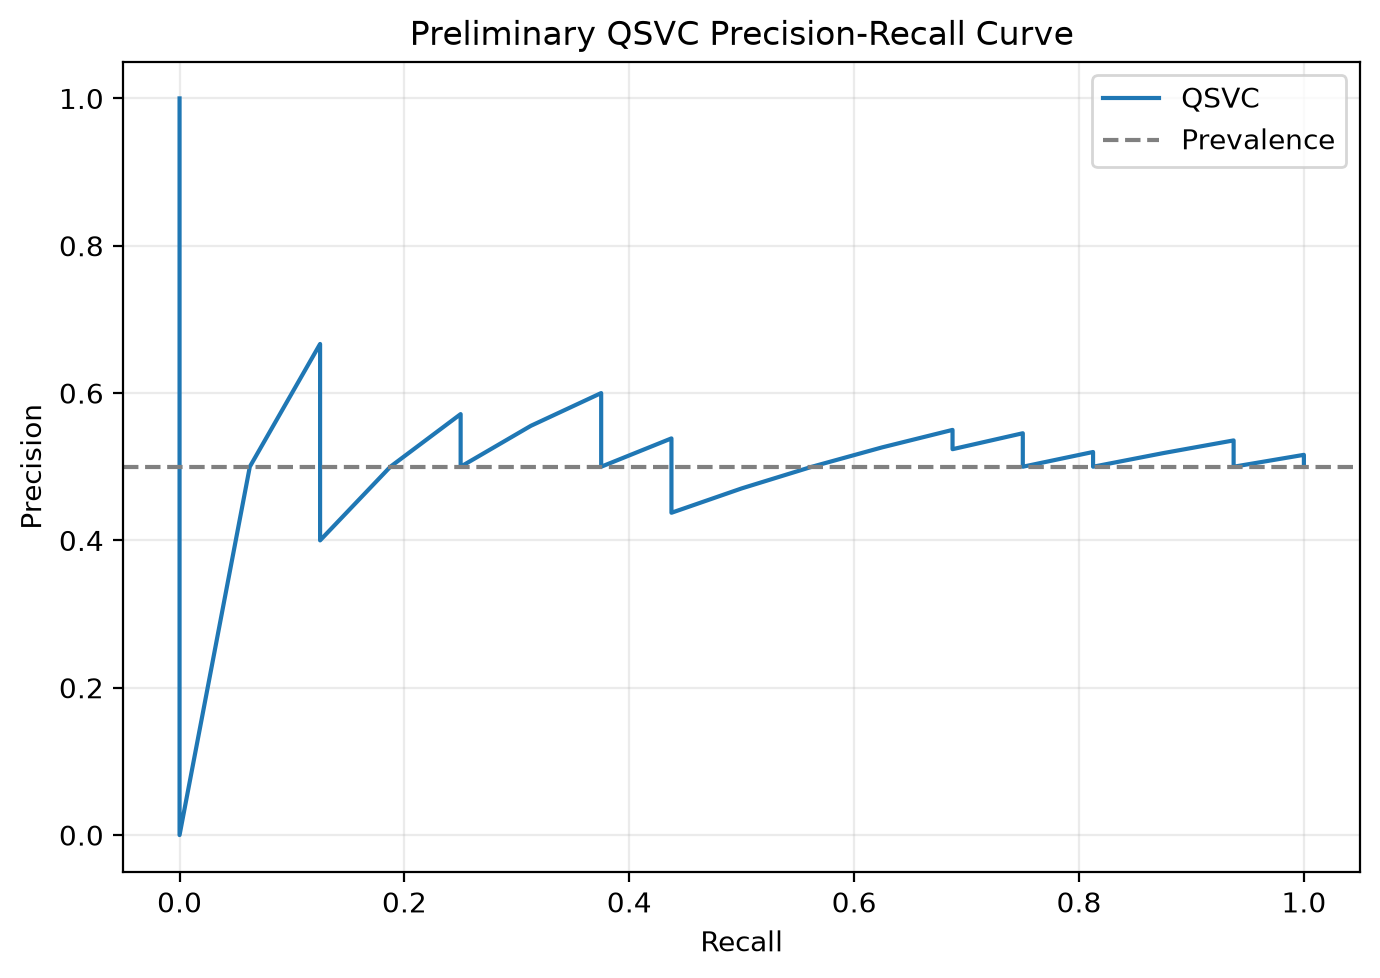

In [5]:
display(Image(filename=str(FIGURES_DIRECTORY / '01_pr_curve.png')))

## 14. ROC curve

The ROC curve uses the saved QSVC decision scores and reports the saved ROC-AUC value.

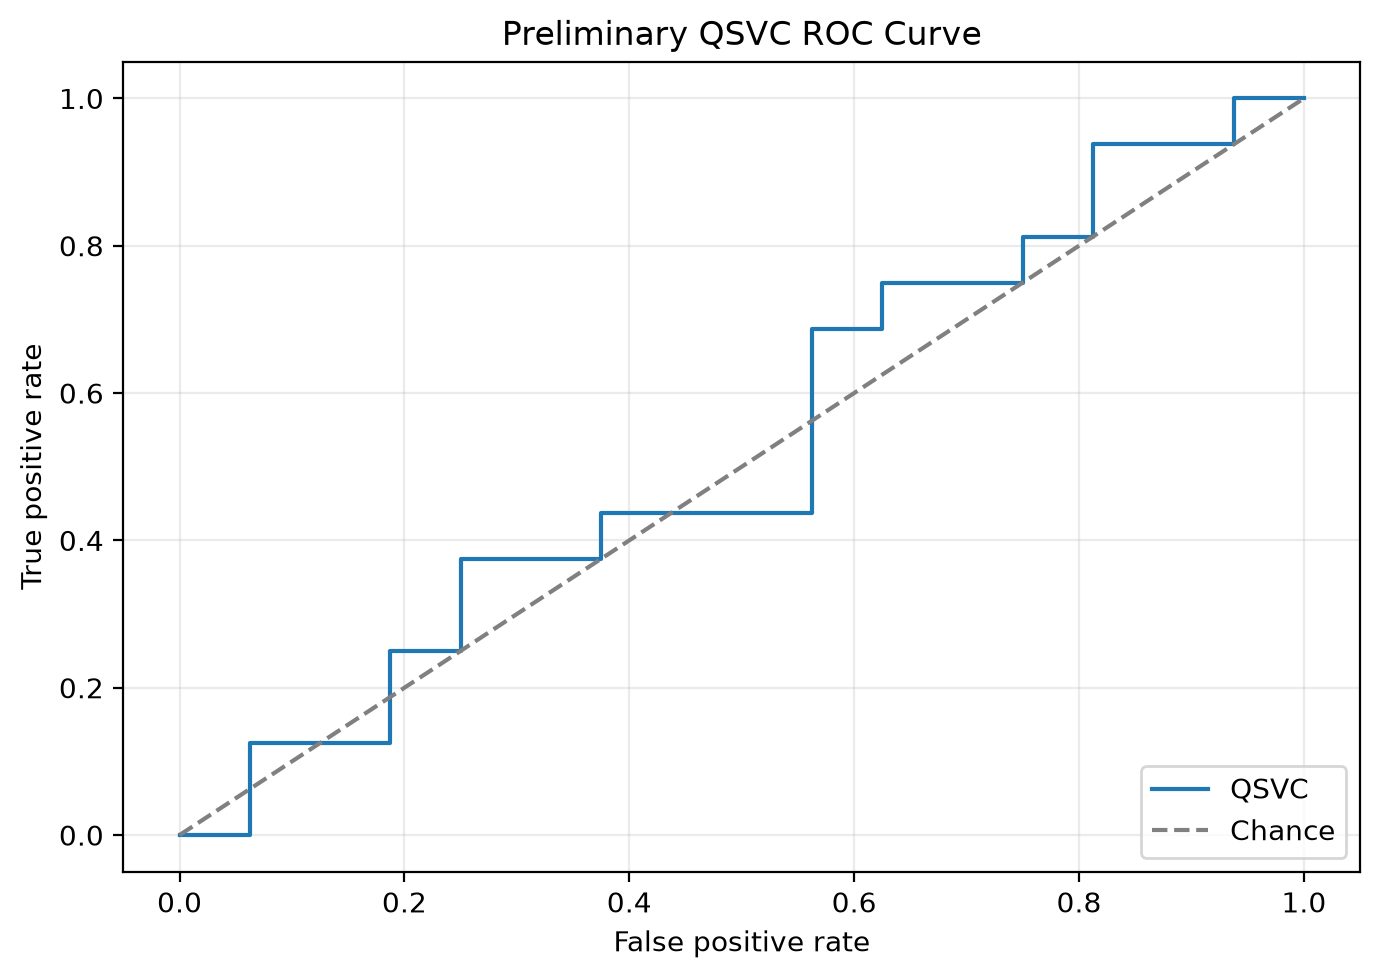

In [6]:
display(Image(filename=str(FIGURES_DIRECTORY / '02_roc_curve.png')))

## 15. Quantum kernel matrix

This heatmap shows the 32 by 32 kernel matrix computed for the training subset.

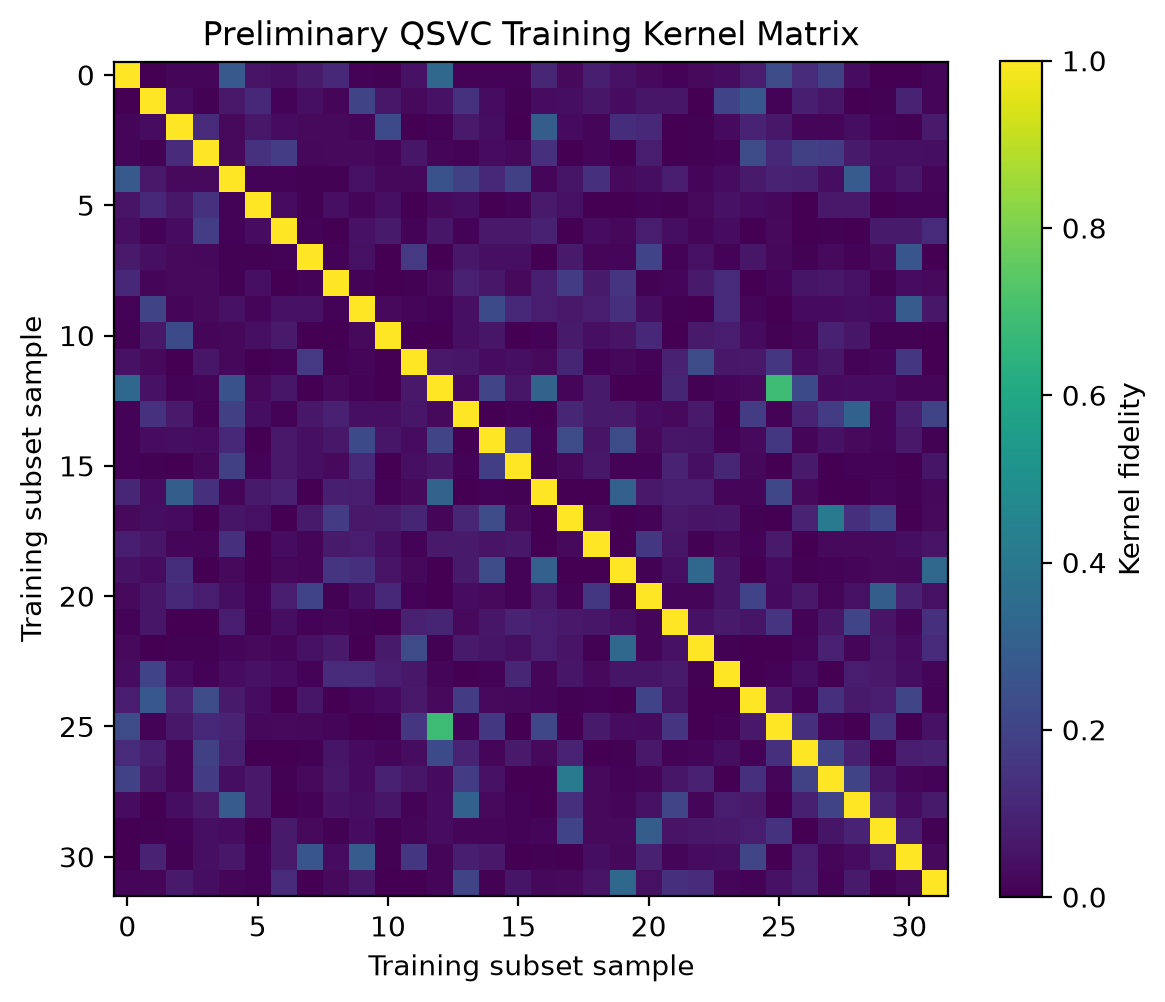

In [7]:
display(Image(filename=str(FIGURES_DIRECTORY / '04_quantum_kernel_matrix.png')))

In [8]:
circuit_text = (FIGURES_DIRECTORY / '05_quantum_feature_map.txt').read_text(encoding='utf-8')
display(Markdown('```text\n' + circuit_text + '\n```'))

```text
   ┌───┐┌───────────┐                                                                                                                              
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──────────────────────────────────────────────────────────────────────────────────────
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐                                                                                    
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■────────────────────────────────────■────────────────────────────────────────────
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐┌──────────────────────────────┐┌─┴─┐                                          
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├┤ P((-π + x[1])*(-π + x[2])*2) ├┤ X ├──■────────────────────────────────────■──
   ├───┤├───────────┤                                          └───┘└──────────────────────────────┘└───┘┌─┴─┐┌──────────────────────────────┐┌─┴─┐
3: ┤ H ├┤ P(2*x[3]) ├────────────────────────────────────────────────────────────────────────────────────┤ X ├┤ P((-π + x[2])*(-π + x[3])*2) ├┤ X ├
   └───┘└───────────┘                                                                                    └───┘└──────────────────────────────┘└───┘

```

## 16. Computational cost

The saved measured runtimes are shown below. The workload estimate is 1,024 training-kernel pairs and up to 1,024 train-to-test inference pairs.

In [9]:
timings = results['timing_seconds']
cost_summary = {
    'kernel construction (seconds)': timings['kernel_construction'],
    'training kernel computation (seconds)': timings['training_kernel_matrix'],
    'QSVC training (seconds)': timings['qsvc_training'],
    'inference (seconds)': timings['inference'],
    'total runtime (seconds)': results['total_runtime_seconds'],
    'training kernel pairs': results['kernel_workload_estimate']['training_kernel_pairs'],
    'inference pairs upper bound': results['kernel_workload_estimate']['inference_train_test_pairs_upper_bound'],
}
display(cost_summary)

{'kernel construction (seconds)': 0.0002132499939762056,
 'training kernel computation (seconds)': 0.8882613750174642,
 'QSVC training (seconds)': 0.8542671670438722,
 'inference (seconds)': 1.7506762919947505,
 'total runtime (seconds)': 4.578687333036214,
 'training kernel pairs': 1024,
 'inference pairs upper bound': 1024}

## 17. Limitations

- The experiment uses only 32 training and 32 test rows because full quantum-kernel evaluation is expensive.
- The test subset is balanced, unlike the original dataset and full classical test partition.
- The QSVM metrics are not directly equivalent to the full-data classical metrics.
- The run is noiseless and uses `StatevectorSampler`; it does not represent Aer noise or hardware results.
- The experiment does not establish quantum advantage.

## 18. Interpretation of the preliminary result

The result demonstrates that the selected four-feature representation, four-qubit feature map, fidelity kernel, and QSVC pipeline can execute end to end on a reproducible small workload. The metrics should be interpreted only as a preliminary functional result for this reduced subset. They should not be used to claim that QSVC is better or worse than the full-data classical models.

## 19. What will be done after the midterm

Future work may address the separately defined temporal protocol, carefully controlled quantum-noise experiments, scaling studies, resource analysis, and final reporting. Those phases are not implemented or evaluated here.

In [10]:
required_files = [RESULTS_PATH, PREDICTIONS_PATH]
required_files.extend(PROJECT_ROOT / relative_path for relative_path in results['figure_files'].values())
assert all(path.exists() for path in required_files)
print('All saved QSVM artifacts exist.')
print('This notebook loads artifacts only; no new QSVC training is performed.')

All saved QSVM artifacts exist.
This notebook loads artifacts only; no new QSVC training is performed.
